In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import s3fs
import xarray as xr
import os
import pandas as pd

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

In [2]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

In [3]:
ds = xr.open_dataset('s3://gaia/cjense/data/oceanthermalforcing/twglaciers2.zarr',                      
                     storage_options=storage_options,
                     zarr_format=3,
                     consolidated=False,
                     mode="r",
                     engine="zarr")

ds

<xarray.Dataset> Size: 214kB
Dimensions:                  (glacier: 3, time_EN4: 312, time_common: 300,
                              depth_EN4: 24, time_runoff: 312)
Coordinates:
  * glacier                  (glacier) int64 24B 0 1 2
    glacier_name             (glacier) <U31 372B ...
  * time_EN4                 (time_EN4) float32 1kB 2e+03 2e+03 ... 2.026e+03
  * time_common              (time_common) float32 1kB 2e+03 2e+03 ... 2.025e+03
  * time_runoff              (time_runoff) float32 1kB 2e+03 2e+03 ... 2.026e+03
Dimensions without coordinates: depth_EN4
Data variables: (12/25)
    ismip6_sector            (glacier) float32 12B ...
    TFmean                   (glacier) float32 12B ...
    Qmean                    (glacier) float32 12B ...
    lat                      (glacier) float32 12B ...
    lon                      (glacier) float32 12B ...
    ocean_EN4_ind            (glacier) float32 12B ...
    ...                       ...
    ocean_average_TF         (glacier, time_common) float32 4kB ...
    runoff_Q                 (glacier, time_runoff) float32 4kB ...
    submelt_m                (glacier, time_common) float32 4kB ...
    submelt_m_EN4            (glacier, time_common) float32 4kB ...
    y                        (glacier) float32 12B ...
    x                        (glacier) float32 12B ...

In [4]:
years = ds.time_common.values
datetime_index = pd.DatetimeIndex([
    pd.Timestamp(year=int(year), month=1, day=1) +
    pd.Timedelta(
        days=(float(year) - int(year)) *
        (366 if pd.Timestamp(
            year=int(year), month=1, day=1
        ).is_leap_year else 365)
    )
    for year in years
])

ds = ds.assign_coords(time_common=datetime_index)

ds.ocean_EN4_TFc

<xarray.DataArray 'ocean_EN4_TFc' (glacier: 3, time_common: 300)> Size: 4kB
[900 values with dtype=float32]
Coordinates:
  * glacier       (glacier) int64 24B 0 1 2
    glacier_name  (glacier) <U31 372B ...
  * time_common   (time_common) datetime64[us] 2kB 2000-01-16T05:38:33.281250...
Attributes:
    description:  EN4 thermal forcing interpolated to common time period 1979...

In [5]:
ds.glacier_name.values

array(['Zachariae Isstrøm', 'Nioghalvfjerdsfjorden (79North)',
       'Helheimgletscher'], dtype='<U31')

In [6]:
zach = ds.ocean_EN4_TFc.sel(glacier=0)
zachdf = zach.to_dataframe()
zachdf = zachdf.drop(columns=['glacier', 'glacier_name'])
zachdf.to_parquet('s3://gaia/cjense/data/oceanthermalforcing/EN4forcing_ZI.parquet', storage_options=storage_options)
zachdf

,ocean_EN4_TFc
time_common,
2000-01-16 05:38:33.281250,3.930954
2000-02-15 18:00:00.000000,4.074294
2000-03-17 06:21:26.718750,4.169587
2000-04-16 17:38:33.281250,4.155910
2000-05-17 06:00:00.000000,3.353546
...,...
2024-08-16 18:00:00.000000,4.206146
2024-09-16 06:21:26.718750,4.411860
2024-10-16 17:38:33.281250,4.512514


In [7]:
data79 = ds.ocean_EN4_TFc.sel(glacier=1)
df79 = data79.to_dataframe()
df79 = df79.drop(columns=['glacier', 'glacier_name'])
df79.to_parquet('s3://gaia/cjense/data/oceanthermalforcing/EN4forcing_79N.parquet', storage_options=storage_options)
df79

,ocean_EN4_TFc
time_common,
2000-01-16 05:38:33.281250,3.766601
2000-02-15 18:00:00.000000,4.065084
2000-03-17 06:21:26.718750,4.407889
2000-04-16 17:38:33.281250,4.332067
2000-05-17 06:00:00.000000,3.348465
...,...
2024-08-16 18:00:00.000000,4.080623
2024-09-16 06:21:26.718750,4.359042
2024-10-16 17:38:33.281250,4.549527


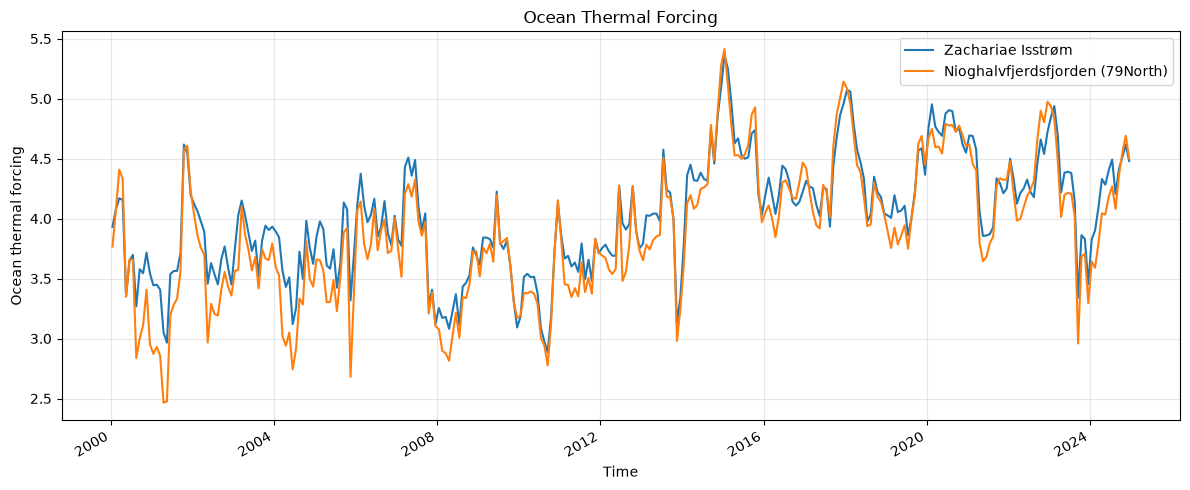

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

zachdf["ocean_EN4_TFc"].plot(ax=ax, label="Zachariae Isstrøm")
df79["ocean_EN4_TFc"].plot(ax=ax, label="Nioghalvfjerdsfjorden (79North)")

ax.set_xlabel("Time")
ax.set_ylabel("Ocean thermal forcing")
ax.set_title("Ocean Thermal Forcing")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig('figures/oceanthermalforcing.png', dpi=300)

plt.tight_layout()
plt.show()